# Week 3: Topic Modeling & Entity Extraction (First Half)

This notebook covers the first part of Week 3 tasks:
1. Ingesting and merging the labeled dataset with the cleaned tokens.
2. Generating a document-term matrix from cleaned/lemmatized tokens using Gensim.
3. Training an LDA model to discover B2B quality topics.
4. Mapping discovered topics to exact human-readable business labels based on top 20 words.
5. Assigning each review its single dominant topic.
6. Saving the trained model, dictionary, intermediate datasets, and visualizations.

### 1. Imports and Config

In [61]:
import os
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.corpora import Dictionary
from gensim.models import LdaModel

# Set relative paths from notebooks/ directory
labeled_data_path = '../outputs/labeled_dataset.csv'
cleaned_data_path = '../data/processed/reviews_cleaned.csv'
lda_model_dir = '../models/lda_model'
stage1_output_path = '../outputs/topics_stage1.csv'
fig_output_path = '../outputs/figures/topic_frequency.png'

print('Setup complete.')

Setup complete.


### 2. Ingest and Align Datasets

Load both `labeled_dataset.csv` and `reviews_cleaned.csv` and merge them on the review text column to bring back the tokens.

In [62]:
df_label = pd.read_csv(labeled_data_path)
df_clean = pd.read_csv(cleaned_data_path)

# Inner join to match exact feedback texts
df_merged = pd.merge(
    df_label,
    df_clean[['feedback_text', 'tokens']],
    left_on='review text',
    right_on='feedback_text',
    how='inner'
)

print(f'Original Labeled rows: {len(df_label)}')
print(f'Merged rows with tokens: {len(df_merged)}')
df_merged.head(2)

Original Labeled rows: 2500
Merged rows with tokens: 2500


,review text,rating,vader_label,distilbert_label,distilbert_confidence,rating_based_truth,feedback_text,tokens
0,Our West India heavy machinery fabricator oper...,4,negative,positive,0.942185,positive,Our West India heavy machinery fabricator oper...,"['west', 'india', 'heavy', 'machinery', 'fabri..."
1,Received 153 MT of Beams and Columns (PF Secti...,3,negative,negative,0.994328,neutral,Received 153 MT of Beams and Columns (PF Secti...,"['received', '153', 'mt', 'beam', 'column', 'p..."


### 3. Format Tokens

Parse the string-serialized token lists back to list of strings using `ast.literal_eval`.

In [63]:
df_merged['tokens_list'] = df_merged['tokens'].apply(ast.literal_eval)
print('First row tokens list sample:', df_merged['tokens_list'].iloc[0][:5])
print('Token lists count:', len(df_merged['tokens_list']))

First row tokens list sample: ['west', 'india', 'heavy', 'machinery', 'fabricator']
Token lists count: 2500


### 4. Create Document-Term Matrix

Build a Gensim dictionary and filter extreme values to omit rare and overly common tokens.

In [64]:
dictionary = Dictionary(df_merged['tokens_list'])

# Filter terms occurring in < 5 documents or > 50% of the documents
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Generate Bag of Words (BoW) corpus
corpus = [dictionary.doc2bow(text) for text in df_merged['tokens_list']]

print(f'Unique dictionary tokens count: {len(dictionary)}')
print(f'BoW corpus sample (first doc): {corpus[0][:10]}')

Unique dictionary tokens count: 2205
BoW corpus sample (first doc): [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]


### 5. Train LDA Topic Model

Train an LDA model with `num_topics=6` for `passes=10` with seed `random_state=42`.

In [65]:
num_topics = 6
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10
)

print('LDA Model trained successfully.')

LDA Model trained successfully.


### 6. Print Top 20 Topic Words and Map Labels

Print top 20 words for each topic and define the label mapping based on their semantic meaning.

In [66]:
for idx in range(num_topics):
    words = [w[0] for w in lda_model.show_topic(idx, topn=20)]
    print(f'Topic {idx}: {words}')

Topic 0: ['transit', 'packaging', 'bundle', 'surface', 'material', 'plant', 'advance', 'site', 'arrived', 'dispatch', 'infrastructure', 'without', 'condition', 'damage', 'strapping', 'intimation', 'hessian', 'coil', 'rail', 'jindal']
Topic 1: ['dispatch', 'plant', 'day', 'rail', 'delivery', 'steel', 'transit', 'railway', 'material', 'logistics', 'lot', 'south', 'order', 'operation', 'arrived', 'quality', 'raigarh', 'angul', 'stockist', 'received']
Topic 2: ['plate', 'coil', 'hr', 'quality', 'surface', 'material', 'consistency', 'fabrication', 'jindal', 'cement', 'operation', 'across', 'without', 'performance', 'supply', 'construction', 'north', 'product', 'characteristic', 'stamping']
Topic 3: ['rebars', 'panther', 'jindal', 'tmt', 'technical', 'construction', 'strength', 'material', 'plant', 'engineer', 'quality', 'service', 'infrastructure', 'office', 'regional', 'structural', 'sale', 'grade', 'specification', 'complaint']
Topic 4: ['term', 'commercial', 'freight', 'payment', 'invoic

Map topics to the exact requested human-readable labels:
- **Topic 0 $
ightarrow$ "packaging and handling"**: transit, packaging, bundle, strapping, hessian, damage
- **Topic 1 $
ightarrow$ "delivery and logistics"**: dispatch, delivery, railway, transit, logistics, delay
- **Topic 2 $
ightarrow$ "product and quality"**: plate, coil, hr, quality, surface, consistency, cement
- **Topic 3 $
ightarrow$ "customer service"**: technical sales, engineer site visits, complaints, service
- **Topic 4 $
ightarrow$ "pricing and commercial"**: commercial terms, payment terms, invoices, credit, GST
- **Topic 5 $
ightarrow$ "technical compliance"**: dimensional tolerances, structural specifications, section profiles

In [67]:
topic_mapping = {
    0: 'packaging and handling',
    1: 'delivery and logistics',
    2: 'product and quality',
    3: 'customer service',
    4: 'pricing and commercial',
    5: 'technical compliance'
}

print('Topic mapping configured.')

Topic mapping configured.


### 7. Assign Dominant Topic to Reviews

Extract dominant topic index for each review and map to the business label.

In [68]:
def get_dominant_topic_label(bow):
    probs = lda_model.get_document_topics(bow)
    dominant = max(probs, key=lambda x: x[1])[0]
    return topic_mapping[dominant]

df_merged['topic_label'] = [get_dominant_topic_label(b) for b in corpus]
df_merged['topic_label'].value_counts()

topic_label
technical compliance      629
customer service          524
packaging and handling    386
delivery and logistics    383
product and quality       326
pricing and commercial    252
Name: count, dtype: int64

### 8. Save Trained LDA Model & Dictionary

Save the LDA model and dictionary to `models/lda_model/` so it can be reloaded later.

In [69]:
os.makedirs(lda_model_dir, exist_ok=True)
lda_model.save(os.path.join(lda_model_dir, 'lda_model'))
dictionary.save(os.path.join(lda_model_dir, 'lda_dict'))

print(f'Model and Dictionary saved in {lda_model_dir}')

Model and Dictionary saved in ../models/lda_model


### 9. Save Intermediate Dataset

Save columns to `outputs/topics_stage1.csv`.

In [70]:
output_columns = [
    'review text',
    'rating',
    'vader_label',
    'distilbert_label',
    'distilbert_confidence',
    'topic_label'
]

df_merged[output_columns].to_csv(stage1_output_path, index=False)
print(f'Intermediate dataset saved to {stage1_output_path}')

Intermediate dataset saved to ../outputs/topics_stage1.csv


### 10. Generate and Save Topic Frequency Chart by Truth Severity Ratings

Plot the frequency bar chart segmented by the ratings-based ground-truth sentiment (`rating_based_truth`) and save it to `outputs/figures/topic_frequency.png`.

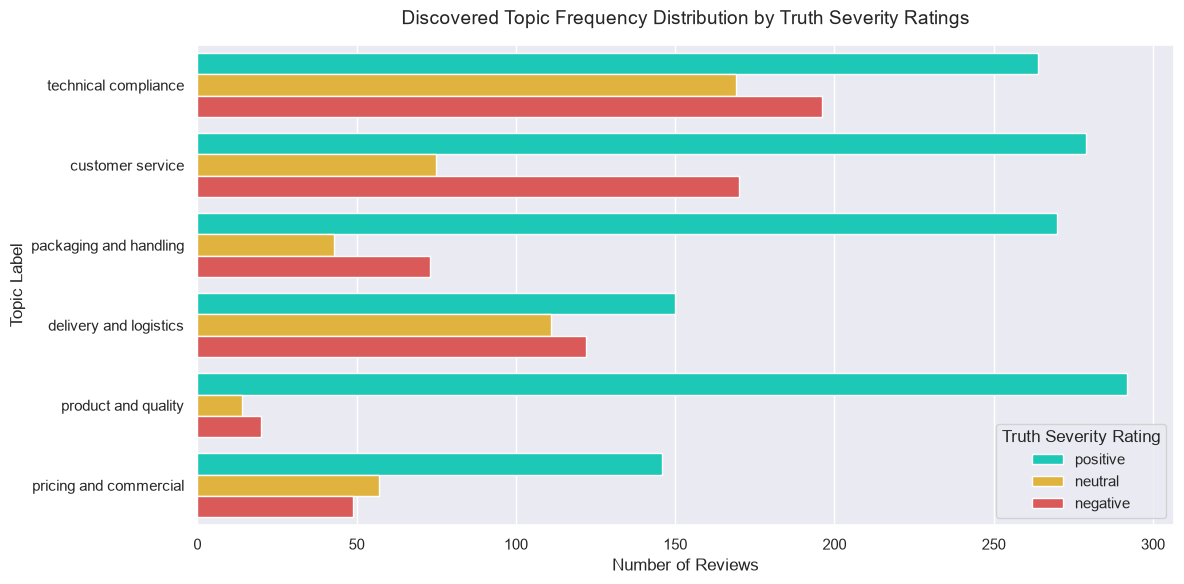

Topic frequency chart saved to ../outputs/figures/topic_frequency.png


In [71]:
plt.figure(figsize=(12, 6))
sns.set_theme(style='darkgrid')
order = df_merged['topic_label'].value_counts().index
ax = sns.countplot(
    data=df_merged,
    y='topic_label',
    hue='rating_based_truth',
    order=order,
    palette={'positive': '#00E5CC', 'neutral': '#FBBF24', 'negative': '#EF4444'}
)
plt.title('Discovered Topic Frequency Distribution by Truth Severity Ratings', fontsize=14, pad=15)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Topic Label', fontsize=12)
plt.legend(title='Truth Severity Rating', loc='lower right')
plt.tight_layout()

os.makedirs(os.path.dirname(fig_output_path), exist_ok=True)
plt.savefig(fig_output_path, dpi=150)
plt.show()

print(f'Topic frequency chart saved to {fig_output_path}')

In [72]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 217.9 kB/s eta 0:00:59
     --------------------------------------- 0.0/12.8 MB 245.8 kB/s eta 0:00:52
     --------------------------------------- 0.1/12.8 MB 595.3 kB/s eta 0:00:22
      --------------------------------------- 0.3/12.8 MB 1.3 MB/s eta 0:00:10
     - -------------------------------------- 0.5/12.8 MB 1.9 MB/s eta 0:00:07
     -- ------------------------------------- 0.8/12.8 MB 2.4 MB/s eta 0:00:06
     --- ------------------------------------ 1.1/12.8 MB 2.8 MB/s eta 0:00:05
     ---- ----------------------------------- 1.3/12.8 MB 3.0 MB/s eta 0:00:04
     ---- ----------------------------------- 1.6/12.8 MB 3.4 MB/s eta 0:00:04
     ----- ---------------------------------- 1.8/12.8 MB 3.5 MB/s eta 0:00:04
     ------ --------------------------------- 2.1/12.8 MB 3.7 M


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import pandas as pd
import spacy
import matplotlib.pyplot as plt

In [74]:
nlp = spacy.load("en_core_web_sm")

In [75]:
df = pd.read_csv("../outputs/topics_stage1.csv")

In [76]:
df.head()

,review text,rating,vader_label,distilbert_label,distilbert_confidence,topic_label
0,Our West India heavy machinery fabricator oper...,4,negative,positive,0.942185,pricing and commercial
1,Received 153 MT of Beams and Columns (PF Secti...,3,negative,negative,0.994328,technical compliance
2,Our chassis fabrication unit in Central India ...,4,positive,positive,0.996286,technical compliance
3,Round Bars procured for our Central India infr...,4,positive,positive,0.999678,technical compliance
4,Our dealership operations benefit tremendously...,4,positive,positive,0.999758,pricing and commercial


In [77]:
def extract_entities(text):
    doc = nlp(str(text))

    entities = []

    for ent in doc.ents:
        entities.append(ent.text)

    return entities

In [78]:
df["entities"] = df["review text"].apply(extract_entities)

In [79]:
df[["review text", "entities"]].head()

,review text,entities
0,Our West India heavy machinery fabricator oper...,"[West India, 361, Billets, Blooms, Raigarh, Ra..."
1,Received 153 MT of Beams and Columns (PF Secti...,"[153, Beams, Columns, Angul, South India, third]"
2,Our chassis fabrication unit in Central India ...,"[Central India, 319, Beams, Columns, Angul]"
3,Round Bars procured for our Central India infr...,"[Round Bars, Central India, 704, MT, Patratu]"
4,Our dealership operations benefit tremendously...,"[JSL, Beams, 199, MT, Raigarh, West India]"


In [80]:
df.to_csv("../outputs/extracted_topics.csv", index=False)

In [81]:
topic_counts = df["topic_label"].value_counts()

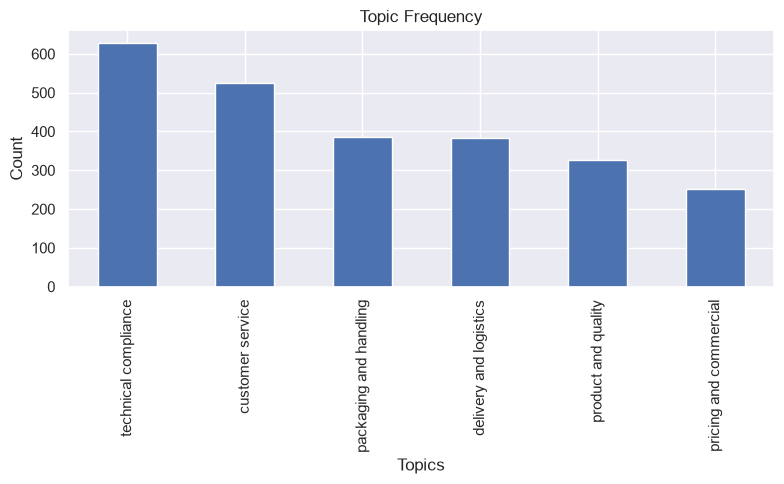

In [82]:
plt.figure(figsize=(8,5))

topic_counts.plot(kind="bar")

plt.title("Topic Frequency")

plt.xlabel("Topics")

plt.ylabel("Count")

plt.tight_layout()

plt.savefig("../outputs/figures/topic_word_distribution.png")

plt.show()

In [83]:
sentiment_topic = pd.crosstab(
    df["topic_label"],
    df["vader_label"]
)

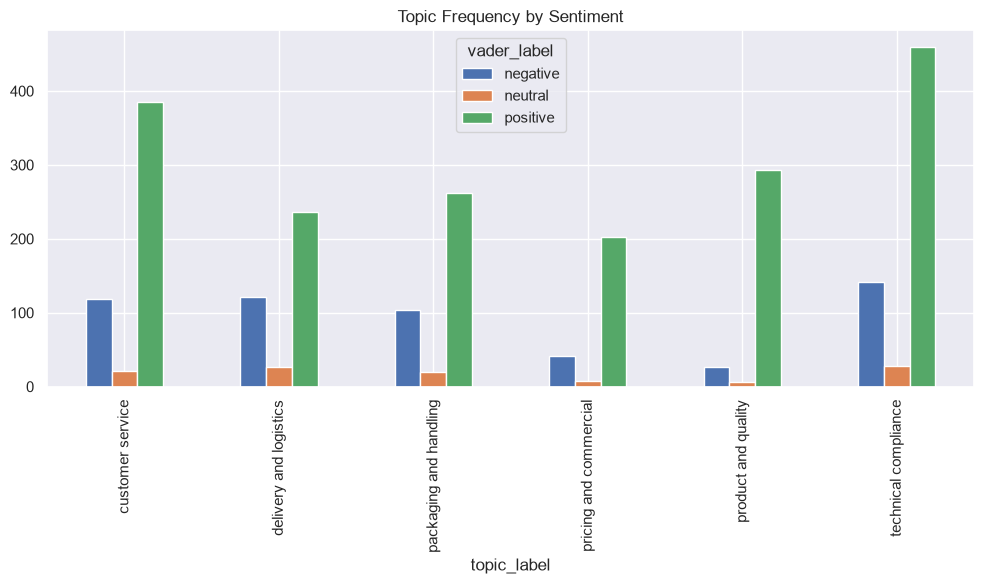

In [84]:
sentiment_topic.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Topic Frequency by Sentiment")

plt.tight_layout()

plt.show()